In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

data = np.loadtxt(
    "data.csv",
    delimiter=",",
    skiprows=1
)

# Features and labels
X = data[:, :8]
y = data[:, 8].astype(int)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = DecisionTreeClassifier(
    criterion="gini",   # or "entropy"
    max_depth=5,        # prevents overfitting
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Error %
error_percent = (
    np.mean(y_pred != y_test)
) * 100

print("Accuracy:", accuracy * 100)
print("Error %:", error_percent)

Accuracy: 74.35897435897436
Error %: 25.64102564102564


implemented decision tree. now time to visualize it...!

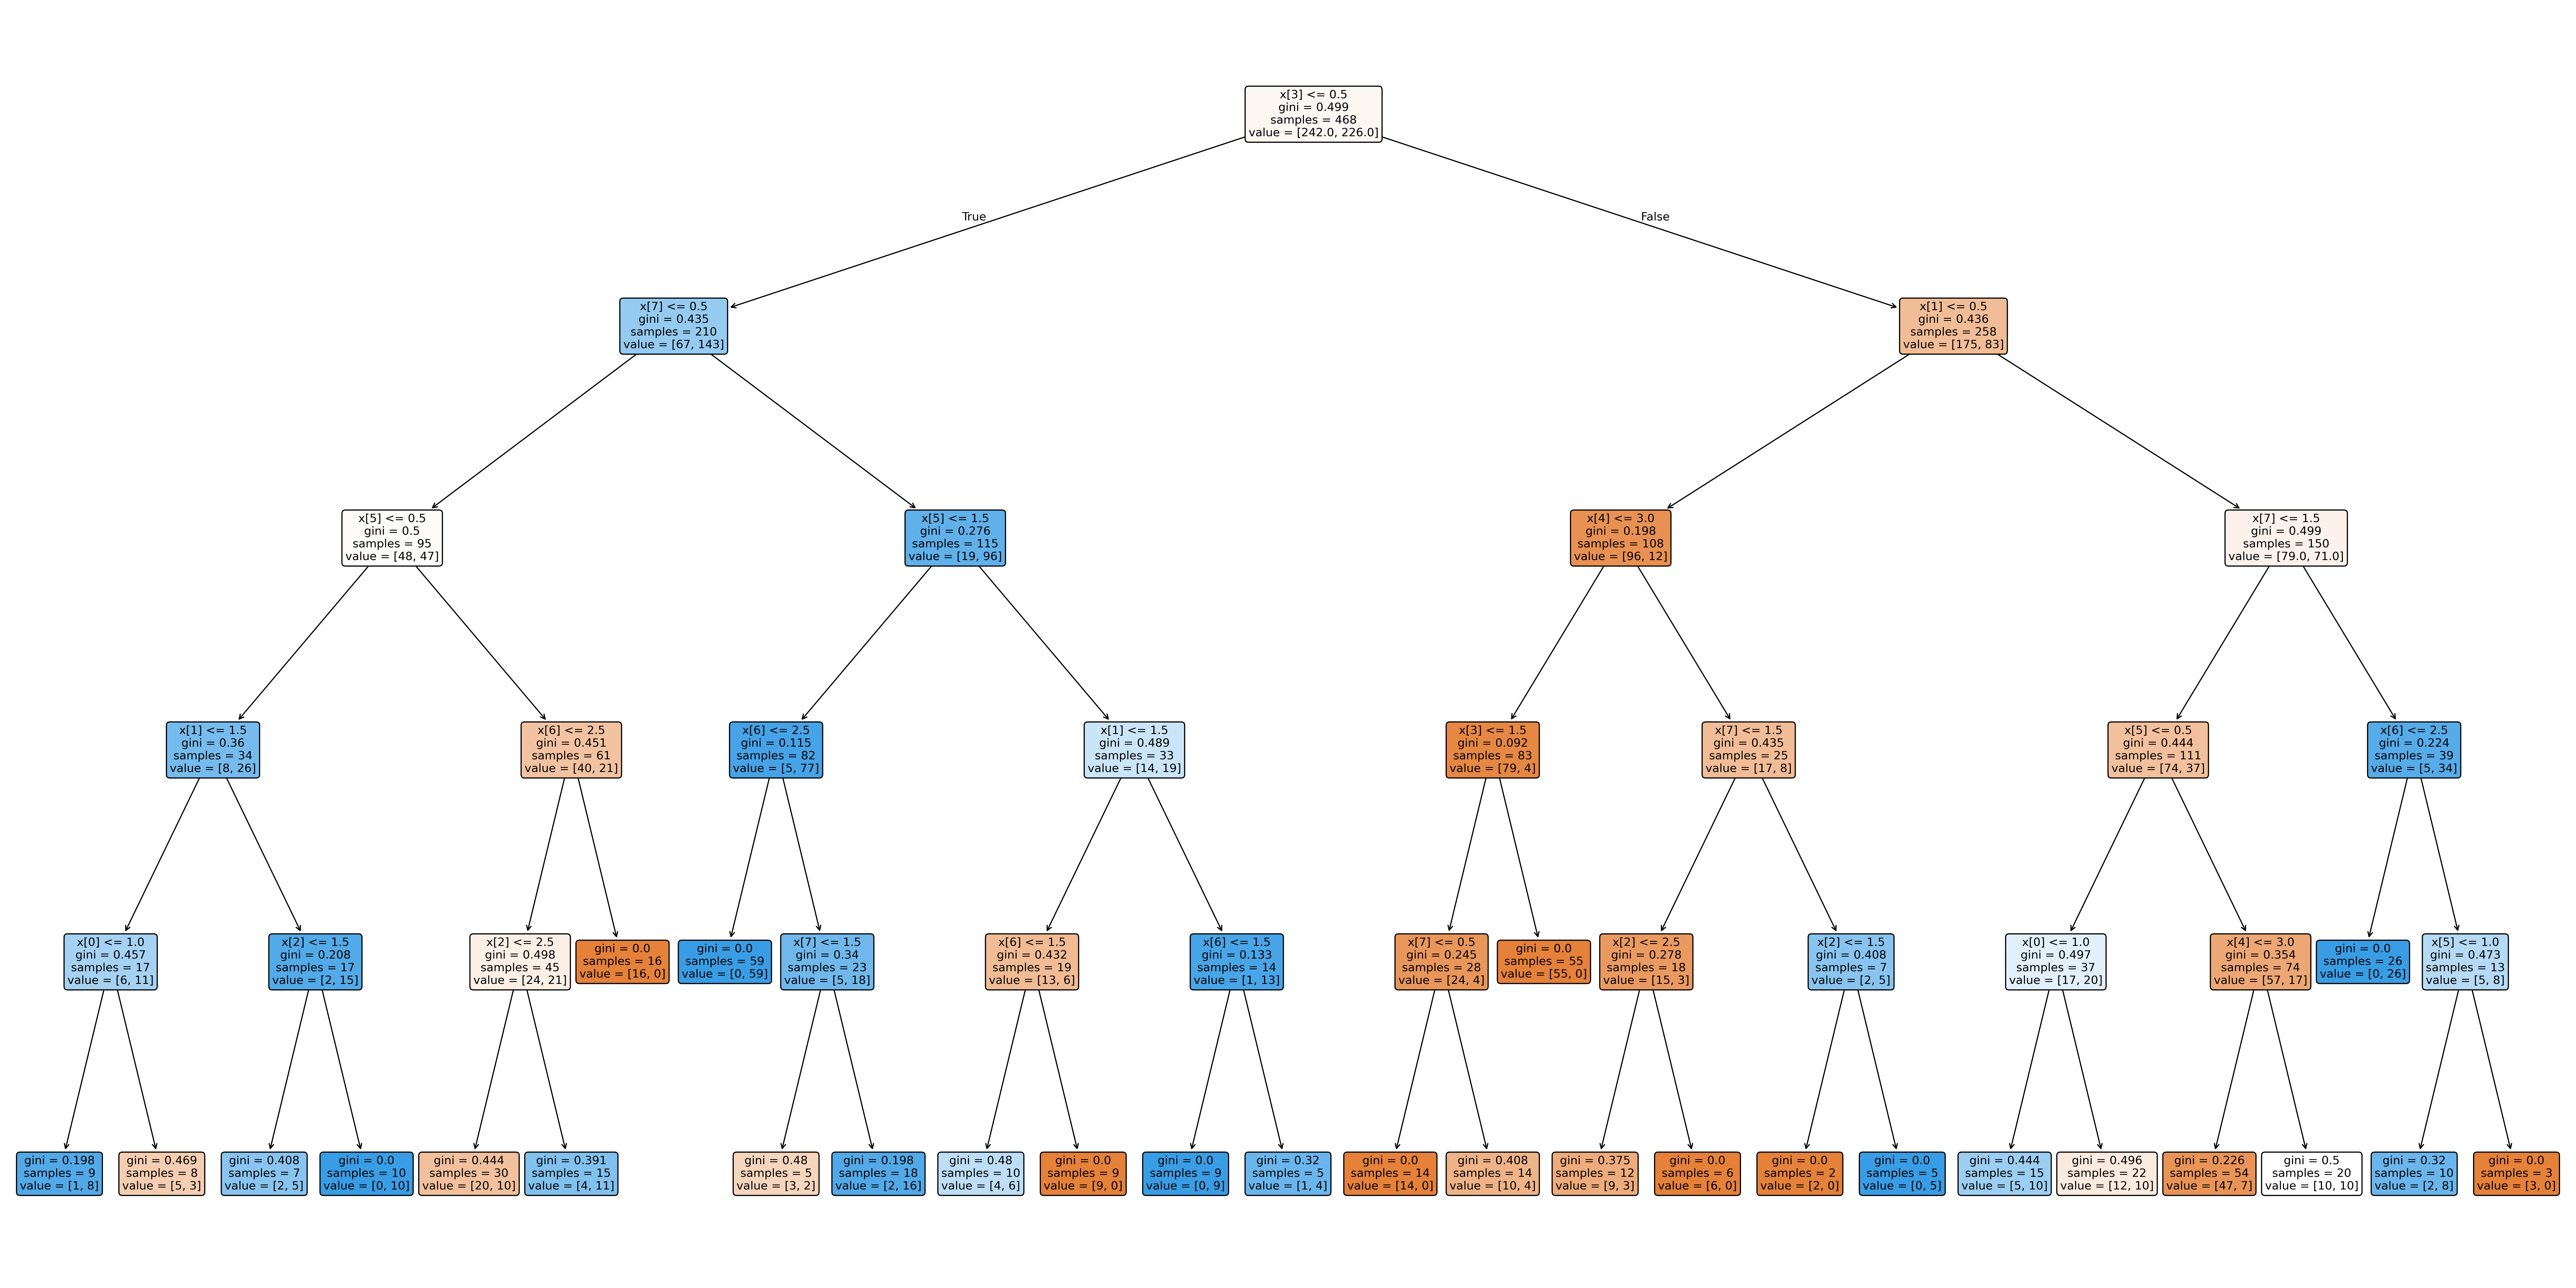

In [6]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(40, 20), dpi=300)

plot_tree(
    model,
    filled=True,
    rounded=True,
    fontsize=10
)



plt.show()

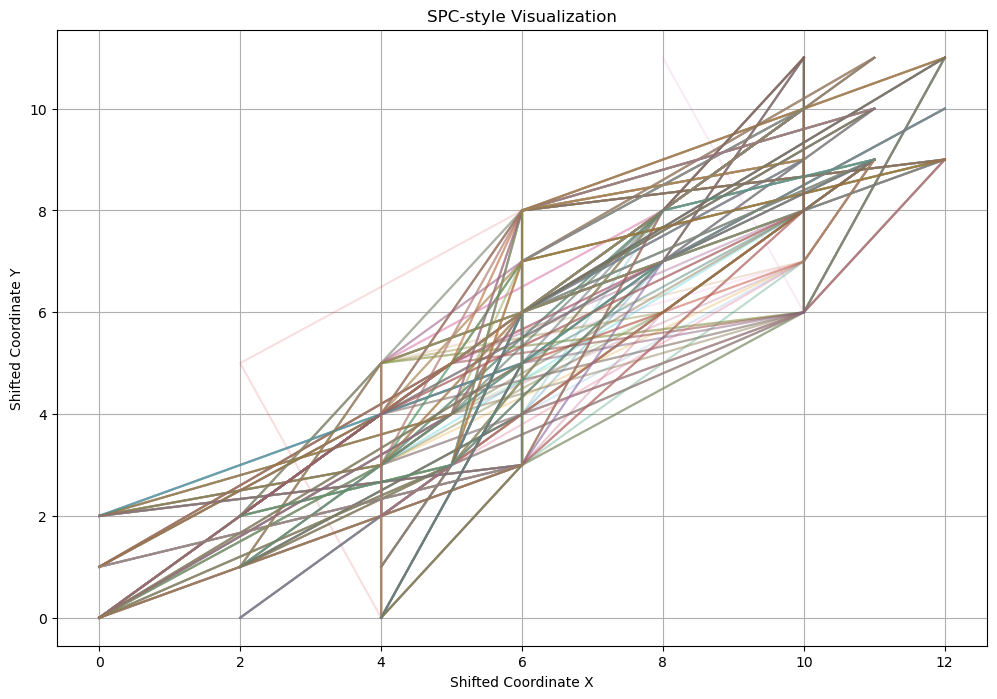

In [7]:

import matplotlib.pyplot as plt

# X = your feature matrix (n_samples, 8)
# y = labels (0 or 1)

def plot_spc(X, y, sample_size=500):
    plt.figure(figsize=(12, 8))

    # reduce clutter
    idx = np.random.choice(
        len(X),
        min(sample_size, len(X)),
        replace=False
    )

    X_plot = X[idx]
    y_plot = y[idx]

    # shifts for paired coordinates
    shifts = [0, 3, 6, 9]

    for x, label in zip(X_plot, y_plot):

        points = [
            (x[0] + shifts[0], x[1] + shifts[0]),
            (x[2] + shifts[1], x[3] + shifts[1]),
            (x[4] + shifts[2], x[5] + shifts[2]),
            (x[6] + shifts[3], x[7] + shifts[3]),
        ]

        xs = [p[0] for p in points]
        ys = [p[1] for p in points]

        alpha = 0.15

        if label == 0:
            plt.plot(xs, ys, alpha=alpha)
        else:
            plt.plot(xs, ys, alpha=alpha)

    plt.xlabel("Shifted Coordinate X")
    plt.ylabel("Shifted Coordinate Y")
    plt.title("SPC-style Visualization")

    plt.grid(True)
    plt.show()


plot_spc(X, y)